In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
import xarray as xr
import shutil
import matplotlib.pyplot as plt

import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

In [2]:
shapefile_path =  Path.home() / "BEP-beau/BEP/code/CatchmentArea" / "CatchmentArea_4326.shp"
experiment_start_date = "1970-01-01T00:00:00Z"
experiment_end_date = "2014-12-31T00:00:00Z"
forcing_path_CMIP = Path.home() / "BEP-beau/BEP/code/CatchmentArea" / "CMIP6_"  
forcing_path_CMIP.mkdir(exist_ok=True)

In [6]:
cmip_historical =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'MPI-ESM1-2-HR',
   "ensemble": 'r1i1p1f1',
   'grid': 'gn'
}

#CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_historical,
#   start_time=experiment_start_date,
#   end_time=experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "historical",)


historical_CMIP_location = forcing_path_CMIP / "historical" / "work" / "diagnostic" / "script"
historical_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location)

In [9]:
cmip_historical_EC =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'EC-Earth3',
   "ensemble": 'r1i1p1f1',
   'grid': 'gr'
}

#CMIP_forcing_EC = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_historical_EC,
#   start_time=experiment_start_date,
#   end_time=experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "historical_EC",)


historical_CMIP_location_EC = forcing_path_CMIP / "historical_EC" / "work" / "diagnostic" / "script"
historical_CMIP_forcing_EC = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location_EC)

In [30]:
cmip_historical2 =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'MPI-ESM1-2-LR',
   "ensemble": 'r1i1p1f1',
   'grid': 'gn'
}

#CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_historical2,
#   start_time=experiment_start_date,
#   end_time=experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "historical2",)


historical_CMIP_location2 = forcing_path_CMIP / "historical2" / "work" / "diagnostic" / "script"
historical_CMIP_forcing2 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location2)

In [31]:
print(historical_CMIP_forcing2)

LumpedMakkinkForcing(
    start_time='1970-01-01T00:00:00Z',
    end_time='2014-12-31T00:00:00Z',
    directory=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/CMIP6_/historical2/work/diagnostic/script'),
    shape=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/CMIP6_/historical2/work/diagnostic/script/Catchment
Area_4326.shp'),
    filenames={
        'pr': 'CMIP6_MPI-ESM1-2-LR_day_historical_r1i1p1f1_pr_gn_1970-2014.nc',
        'tas': 'CMIP6_MPI-ESM1-2-LR_day_historical_r1i1p1f1_tas_gn_1970-2014.nc',
        'rsds': 'CMIP6_MPI-ESM1-2-LR_day_historical_r1i1p1f1_rsds_gn_1970-2014.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

In [11]:
pr = xr.open_dataset(historical_CMIP_forcing['pr'])
tas = xr.open_dataset(historical_CMIP_forcing['tas'])
rsds = xr.open_dataset(historical_CMIP_forcing['rsds'])
evspsblpot = xr.open_dataset(historical_CMIP_forcing['evspsblpot'])

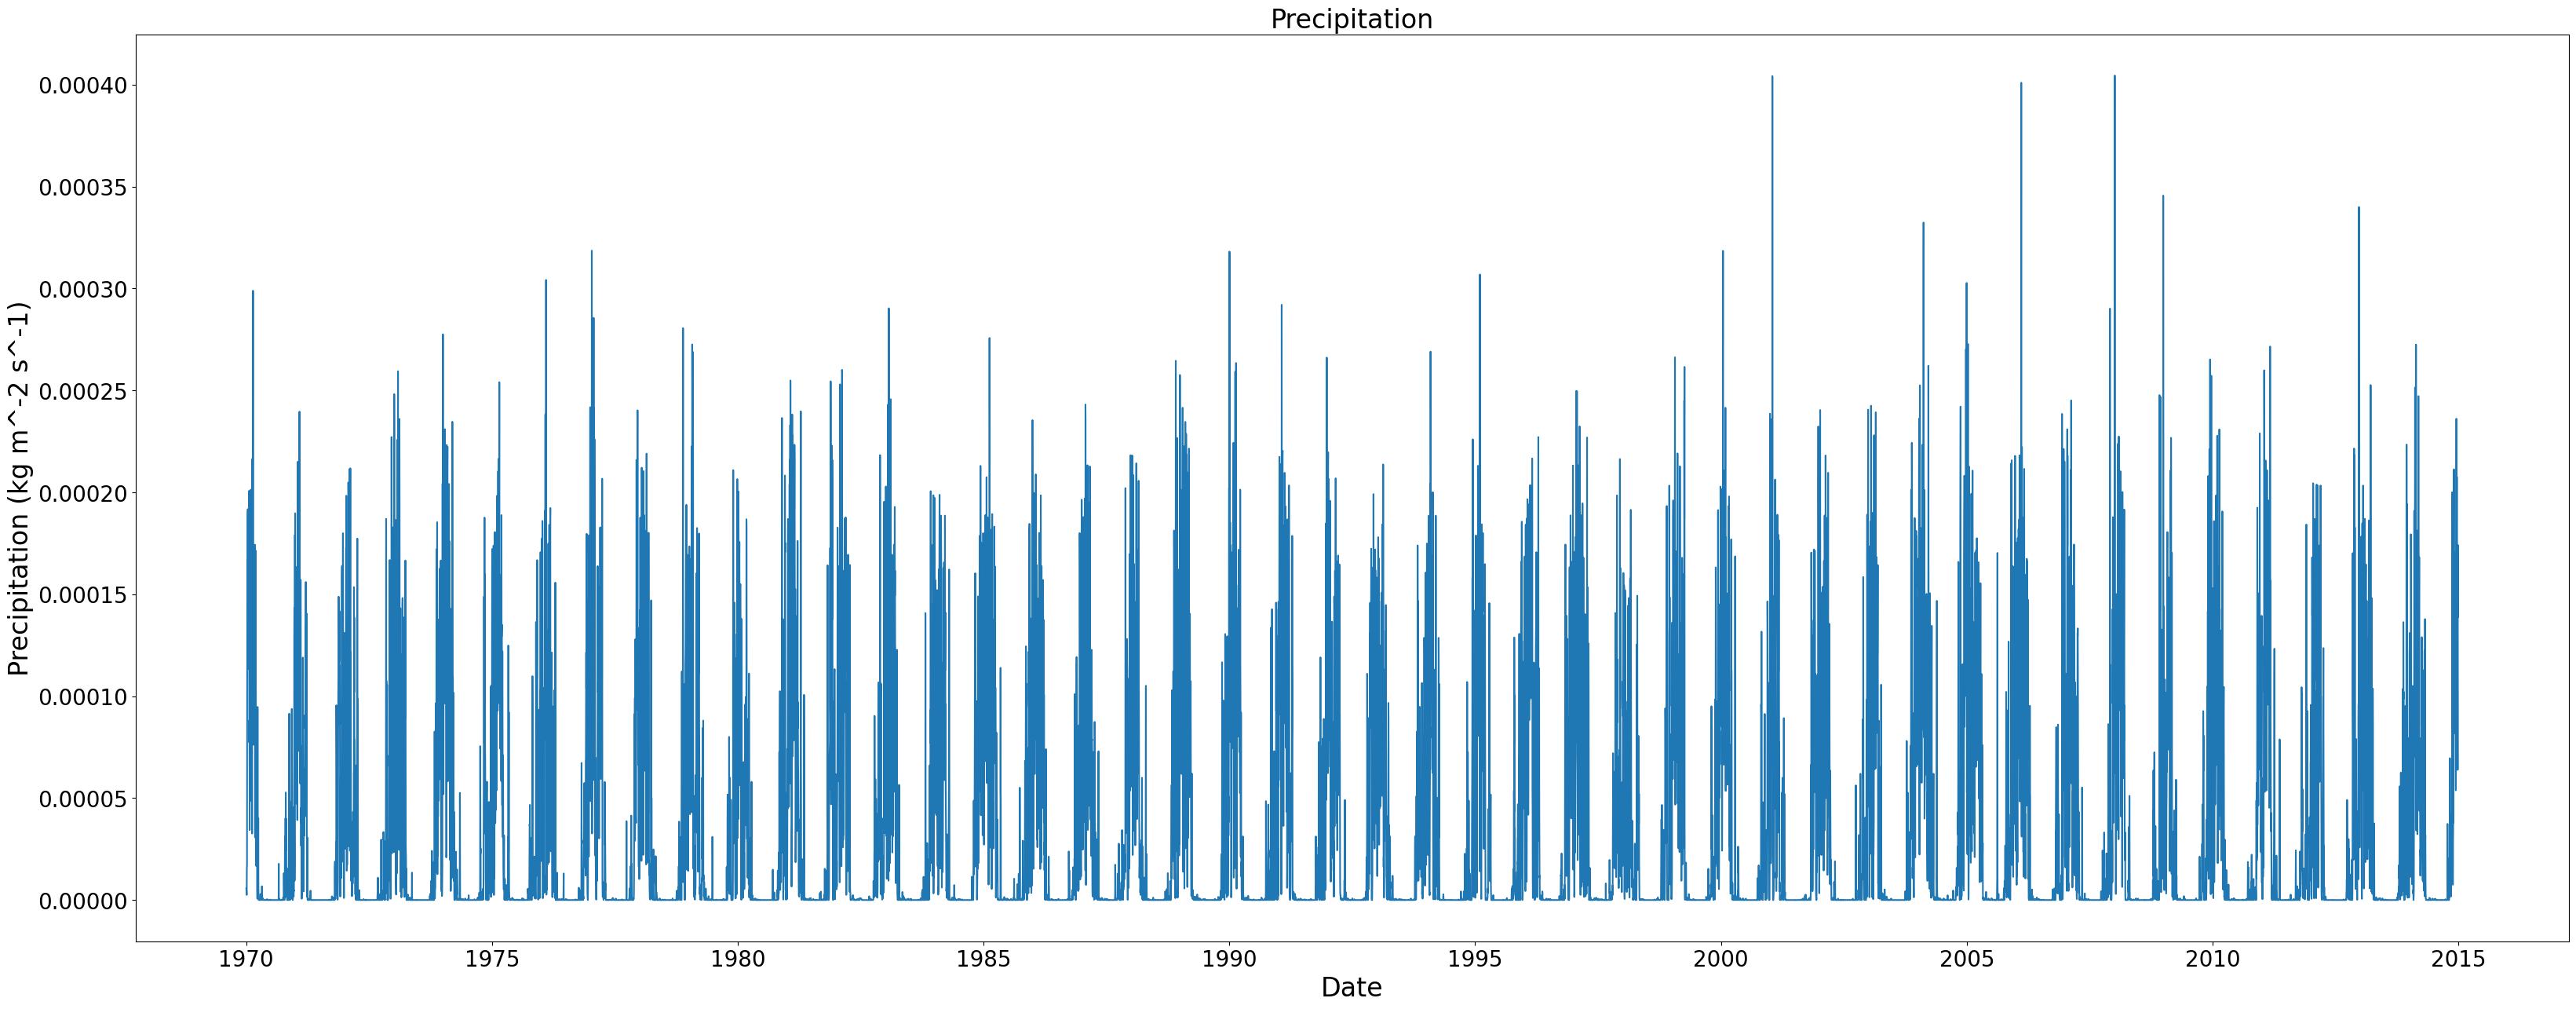

In [12]:
fig, ax = plt.subplots(figsize=(40, 15))
pr['pr'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Precipitation (kg m^-2 s^-1)", fontsize=24)
plt.title("Precipitation", fontsize=24);

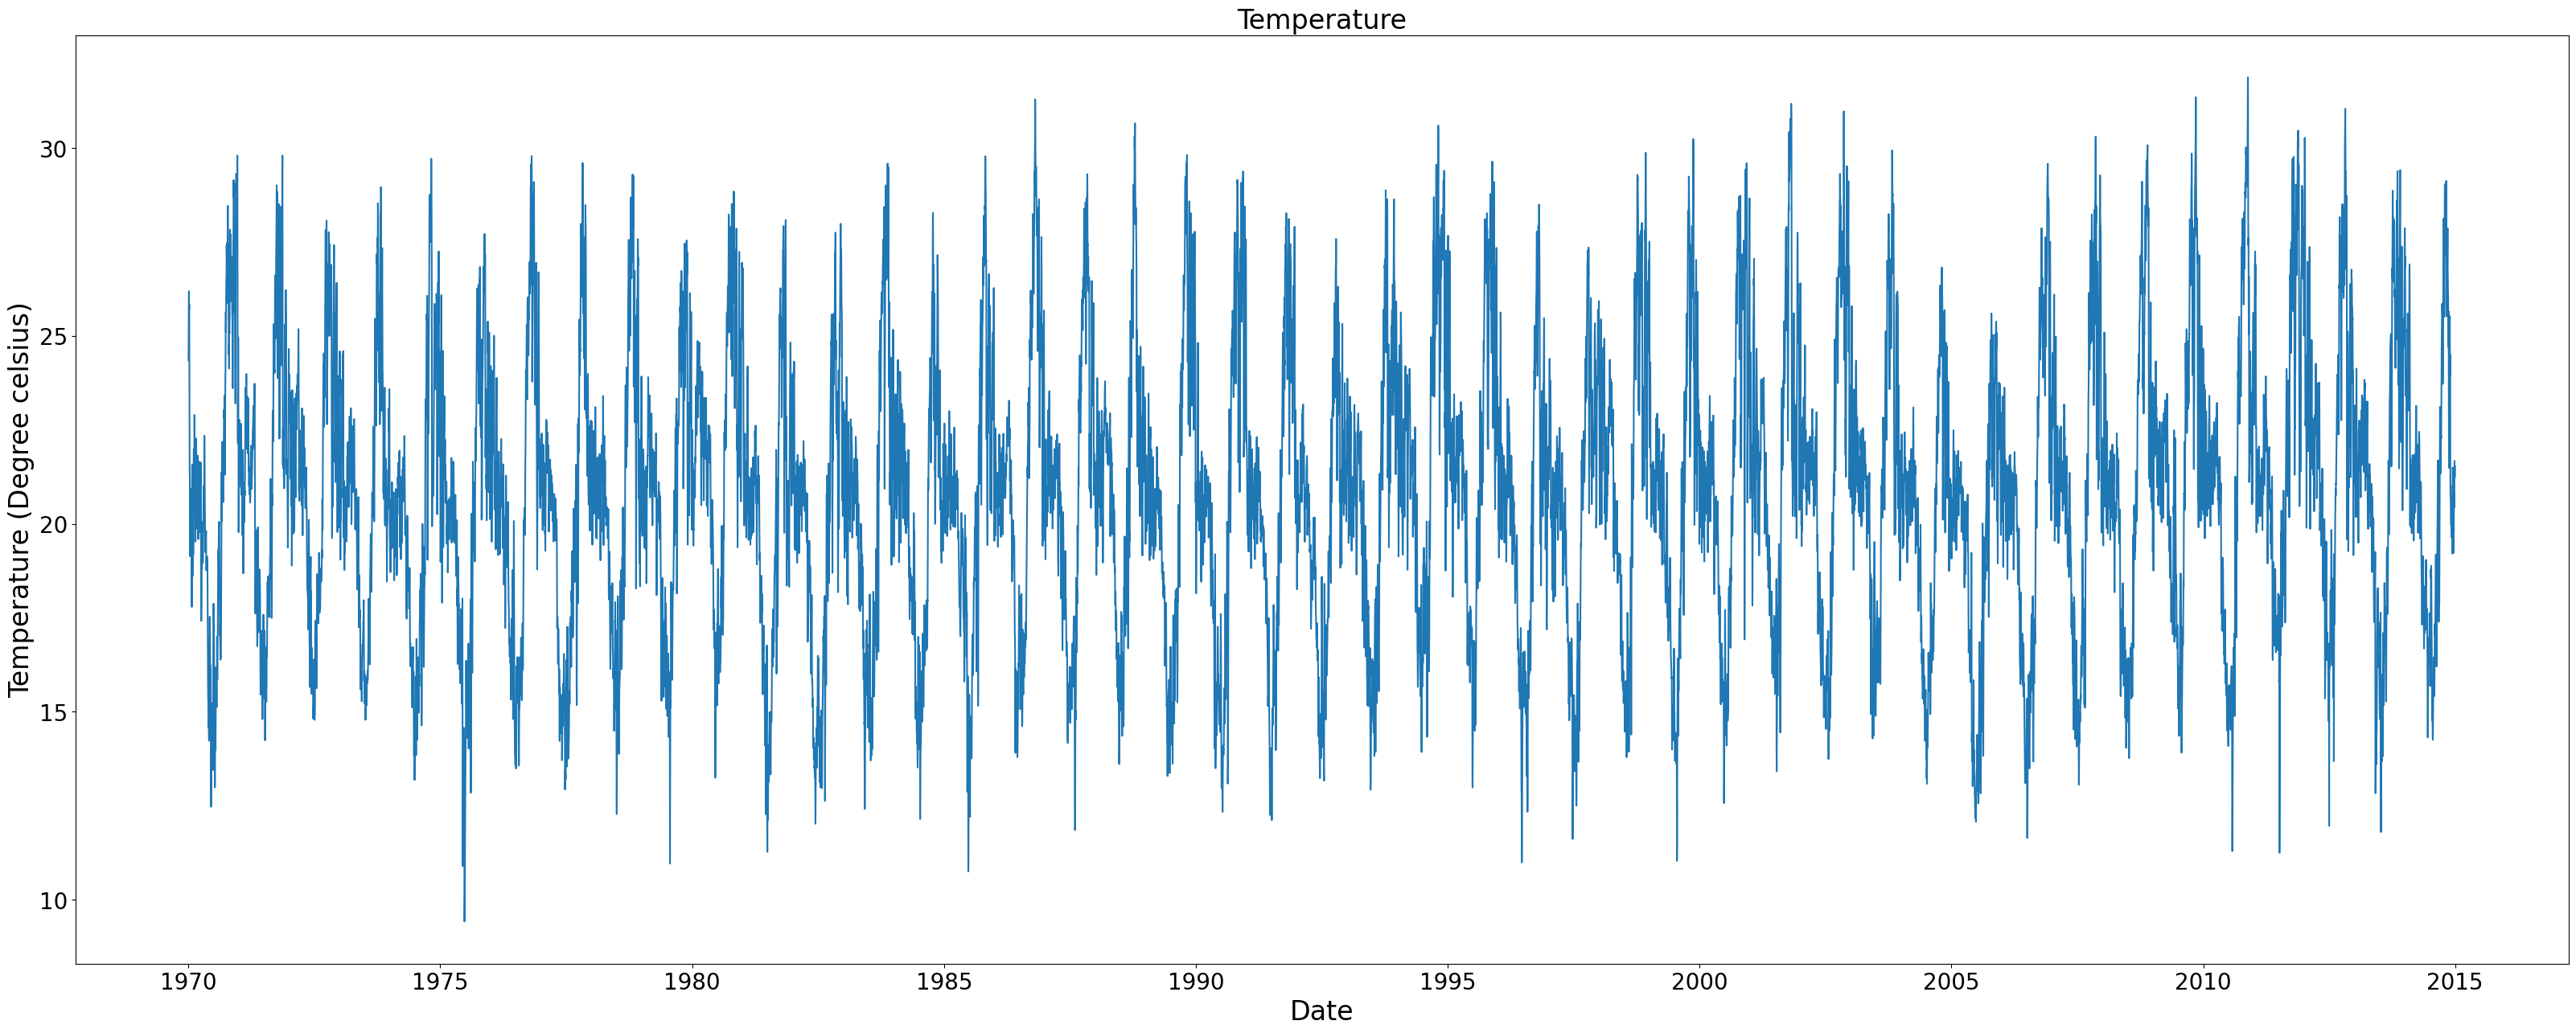

In [13]:
tas['tas'] = tas['tas'] - 273.15

fig, ax = plt.subplots(figsize=(40, 15))
tas['tas'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Temperature (Degree celsius)", fontsize=24)
plt.title("Temperature", fontsize=24);

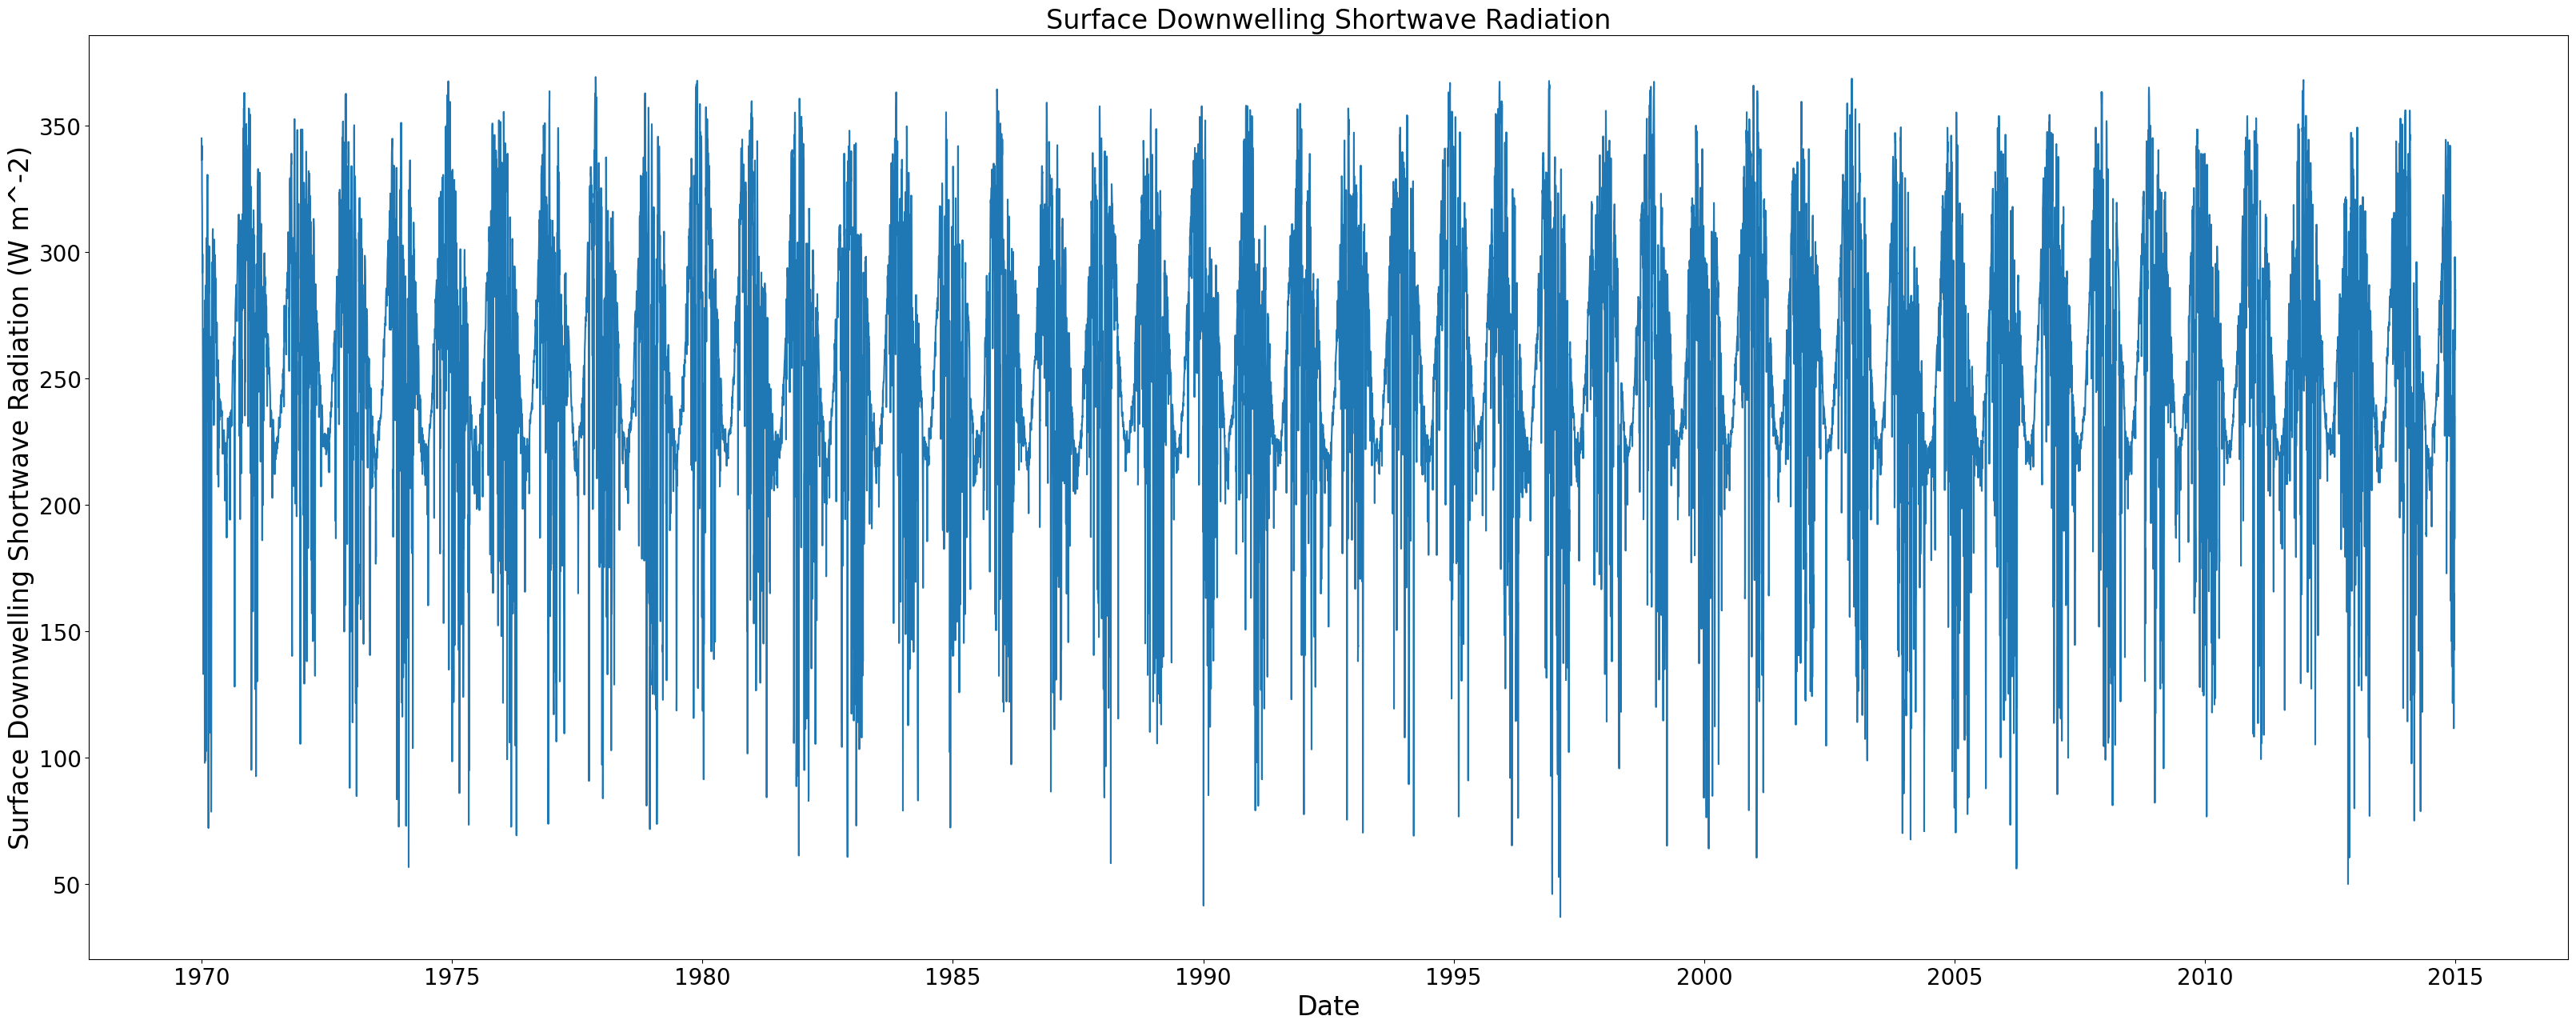

In [14]:
fig, ax = plt.subplots(figsize=(40, 15))
rsds['rsds'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Surface Downwelling Shortwave Radiation (W m^-2)", fontsize=24)
plt.title("Surface Downwelling Shortwave Radiation", fontsize=24);

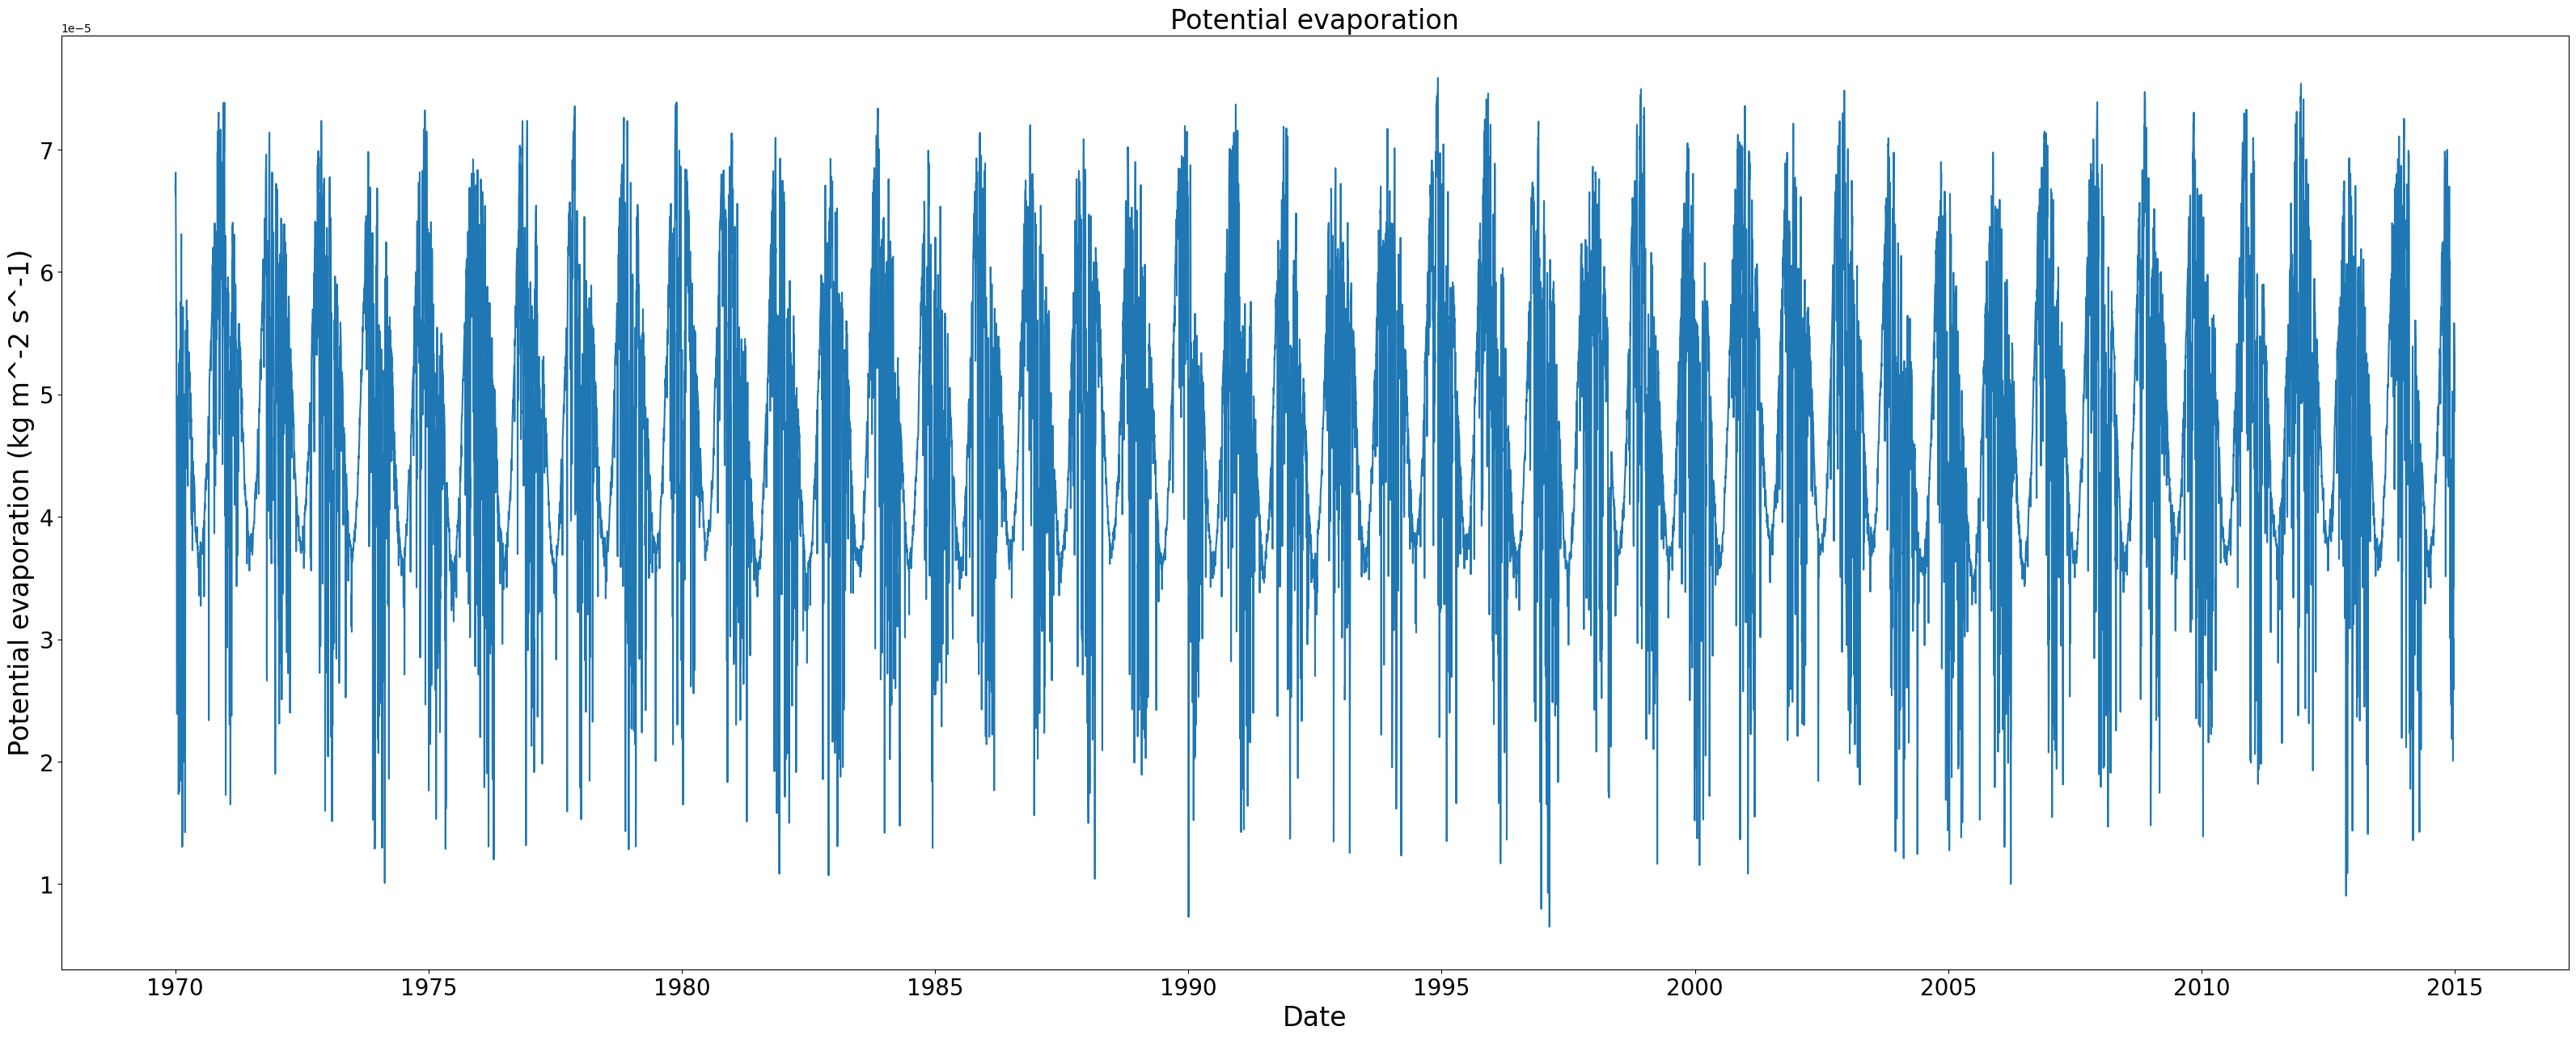

In [15]:
fig, ax = plt.subplots(figsize=(40, 15))
evspsblpot['evspsblpot'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Potential evaporation (kg m^-2 s^-1)", fontsize=24)
plt.title("Potential evaporation", fontsize=24);

In [16]:
data = pd.read_csv("mohembo_daily_water_discharge_data.csv", index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2015, 2016, 2017, 2018, 2019, 2020, 2021])]

In [17]:
Area_km2 = 173696.852

def mmday_to_m3s(Q_sim_mmday, area_km2):
    return (Q_sim_mmday * area_km2) / 86.4

In [19]:
par_0 = [7.00392414e+00, 4.12282990e-01, 2.24893758e+03, 2.73819672e+00,
       1.84946158e-01, 2.24829623e+01, 1.49246751e-02, 6.55485347e-04,
       3.72295856e-01]

param_names = ["Imax",
               "Ce",
               "Sumax",
               "Beta",
               "Pmax",
               "Tlag",
               "Kf",
               "Ks",
               "FM"
               ]

print(list(zip(param_names, par_0)))

[
    ('Imax', 7.00392414),
    ('Ce', 0.41228299),
    ('Sumax', 2248.93758),
    ('Beta', 2.73819672),
    ('Pmax', 0.184946158),
    ('Tlag', 22.4829623),
    ('Kf', 0.0149246751),
    ('Ks', 0.000655485347),
    ('FM', 0.372295856)
]

In [32]:
s_0 = np.array([0,  100,  0,  5,  0])

In [47]:
model = ewatercycle.models.HBV(forcing=historical_CMIP_forcing_EC)

In [48]:
config_file, _ = model.setup(parameters=par_0, initial_storage=s_0)

In [49]:
model.initialize(config_file)

In [50]:
Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [51]:
model.finalize()

In [52]:
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

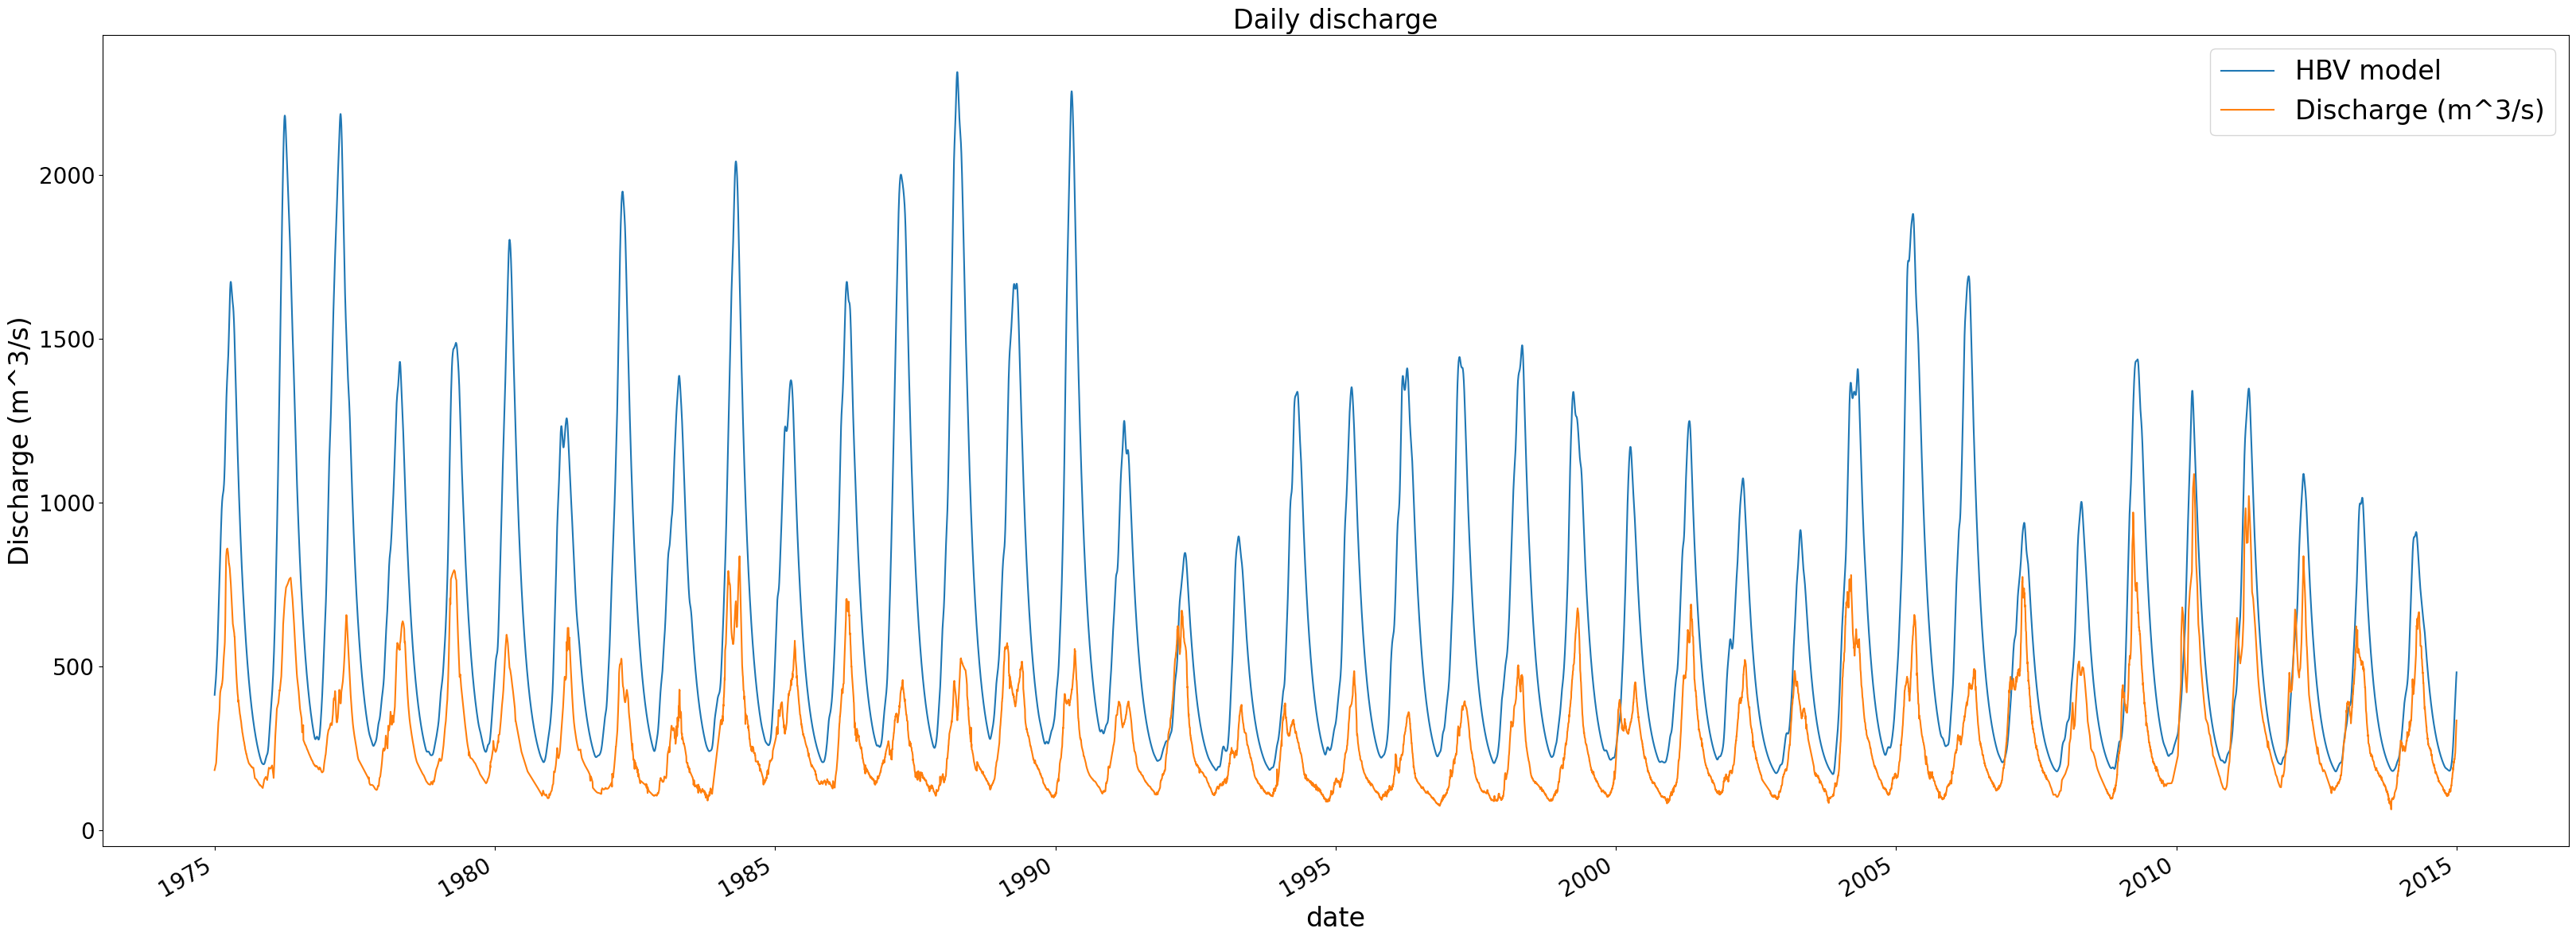

In [53]:
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd['1975'::].plot(ax=ax)
data_daily.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('Daily discharge', fontsize=24)
plt.ylabel("Discharge (m^3/s)");